In [1]:
import os
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
import timm
from transformers import CvtForImageClassification
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score
warnings.filterwarnings("ignore")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print("Gerekli kutuphaneler ve global ayarlar yuklendi.")

c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Gerekli kutuphaneler ve global ayarlar yuklendi.


In [2]:
# --- KONFIGURASYON (CvT-13 + Aug) ---
MODEL_NAME = 'cvt_13'
EXPERIMENT_NAME = "CvT13_Aug_TargetCW_Run2"
# Hiperparametreler
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.00008
NUM_CLASSES = 8
DROPOUT_RATE = 0.1
DROP_PATH_RATE = 0.05
WEIGHT_DECAY = 0.0005
LABEL_SMOOTHING = 0.02
INPUT_SIZE = 224
USE_CLASS_WEIGHTED_LOSS = True
TARGET_CLASS_WEIGHT_MULTIPLIERS = {'esophagitis': 1.12, 'normal-z-line': 1.12}
TARGET_CW_TAG = "ez112"
FORCE_WEIGHTED_SAMPLER = False
EARLY_STOPPING_PATIENCE = 4
EARLY_STOPPING_METRIC = 'val_macro_f1'
NUM_WORKERS = 0 if os.name == 'nt' else 4
# Calistirma etiketleri (ciktilarin karismamasi icin)
dropout_tag = f"dropout{int(round(DROPOUT_RATE * 10)):02d}"
droppath_tag = f"dp{int(round(DROP_PATH_RATE * 100)):02d}"
ls_tag = f"ls{int(round(LABEL_SMOOTHING * 100)):02d}"
wd_tag = f"wd{str(WEIGHT_DECAY).replace('.', 'p').replace('-', 'm')}"
lr_tag = f"lr{LEARNING_RATE:g}".replace(".", "p")
input_tag = f"i{INPUT_SIZE}"
sampler_tag = "smpON" if FORCE_WEIGHTED_SAMPLER else "smpOFF"
cwl_tag = "cwlON" if USE_CLASS_WEIGHTED_LOSS else "cwlOFF"
RUN_TAG = f"{dropout_tag}_{droppath_tag}_{ls_tag}_{wd_tag}_bs{BATCH_SIZE}_ep{EPOCHS}_{lr_tag}_{input_tag}_augON_{sampler_tag}_{cwl_tag}_{TARGET_CW_TAG}"
RUN_NAME = f"{EXPERIMENT_NAME}_{RUN_TAG}"
cwd = os.getcwd()
if os.path.isdir(os.path.join(cwd, "data", "prepared-data")):
    PROJECT_ROOT = cwd
elif os.path.isdir(os.path.join(cwd, "..", "data", "prepared-data")):
    PROJECT_ROOT = os.path.abspath(os.path.join(cwd, ".."))
else:
    PROJECT_ROOT = cwd
DATA_DIR = os.path.join(PROJECT_ROOT, "data", "prepared-data")
OUTPUT_DIR = os.path.join(PROJECT_ROOT, "models", "pytorch", RUN_NAME)
RESULT_OUTPUT_DIR = os.path.join(PROJECT_ROOT, "outputs", MODEL_NAME)
PLOTS_DIR = os.path.join(RESULT_OUTPUT_DIR, "plots", "aug")
REPORTS_DIR = os.path.join(RESULT_OUTPUT_DIR, "reports")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, f"best_{MODEL_NAME}.pth")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"CWD: {cwd}")
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"Cihaz: {DEVICE}")
print(f"Model: {MODEL_NAME}")
print(f"Run Tag: {RUN_TAG}")
print(f"Veri Yolu: {DATA_DIR}")
print(f"Kayit Yeri: {OUTPUT_DIR}")
print(f"Best Model Yolu: {BEST_MODEL_PATH}")
print(f"Weight Decay: {WEIGHT_DECAY}")
print(f"Label Smoothing: {LABEL_SMOOTHING}")
print(f"Drop Path Rate: {DROP_PATH_RATE}")
print(f"Class Weighted Loss: {USE_CLASS_WEIGHTED_LOSS}")
print(f"Target Class Weight Multipliers: {TARGET_CLASS_WEIGHT_MULTIPLIERS}")
print(f"Force Weighted Sampler: {FORCE_WEIGHTED_SAMPLER}")
print(f"Input Size: {INPUT_SIZE}")
print(f"Early Stopping Patience: {EARLY_STOPPING_PATIENCE}")
print(f"Early Stopping Metric: {EARLY_STOPPING_METRIC}")
print(f"Plots Dir: {PLOTS_DIR}")
print(f"Reports Dir: {REPORTS_DIR}")

CWD: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\CVT
PROJECT_ROOT: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison
Cihaz: cuda
Model: cvt_13
Run Tag: dropout01_dp05_ls02_wd0p0005_bs32_ep50_lr8e-05_i224_augON_smpOFF_cwlON_ez112
Veri Yolu: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\data\prepared-data
Kayit Yeri: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\models\pytorch\CvT13_Aug_TargetCW_Run2_dropout01_dp05_ls02_wd0p0005_bs32_ep50_lr8e-05_i224_augON_smpOFF_cwlON_ez112
Best Model Yolu: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\models\pytorch\CvT13_Aug_TargetCW_Run2_dropout01_dp05_ls02_wd0p0005_bs32_ep50_lr8e-05_i224_augON_smpOFF_cwlON_ez112\best_cvt_13.pth
Weight Decay: 0.0005
Label Smoothing: 0.02
Drop Path Rate: 0.05
Class Weighted Loss: True
Target Class Weight Multipliers: {'esophagitis': 1.12, 'normal-z-line': 1.12}
Force Weighted Sampler: False
Input Size: 224
Early Stopping Pati

In [3]:
# ImageNet Normalize Degerleri
mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
# Veri Donusumleri (egitimde kontrollu augmentation acik)
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.RandomResizedCrop(INPUT_SIZE, scale=(0.94, 1.0), ratio=(0.97, 1.03)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=5),
        transforms.RandomApply([
            transforms.ColorJitter(brightness=0.05, contrast=0.06, saturation=0.03, hue=0.0)
        ], p=0.25),
        transforms.RandomAutocontrast(p=0.10),
        transforms.RandomApply([
            transforms.RandomAffine(degrees=0, translate=(0.01, 0.01), scale=(0.99, 1.01))
        ], p=0.20),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
    'val': transforms.Compose([
        transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
    'test': transforms.Compose([
        transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])
}
# Datasetleri Olustur
image_datasets = {x: datasets.ImageFolder(os.path.join(DATA_DIR, x), data_transforms[x])
                  for x in ['train', 'val', 'test']}
# Class-weighted loss ve opsiyonel sampler icin egitim seti sinif agirliklari
train_targets = np.array(image_datasets['train'].targets)
class_counts = np.bincount(train_targets, minlength=NUM_CLASSES)
class_weights = class_counts.sum() / (NUM_CLASSES * np.maximum(class_counts, 1))
class_names = image_datasets['train'].classes
for class_name, multiplier in TARGET_CLASS_WEIGHT_MULTIPLIERS.items():
    if class_name in class_names:
        class_weights[class_names.index(class_name)] *= multiplier
CLASS_WEIGHTS_TENSOR = torch.tensor(class_weights, dtype=torch.float32)
train_sampler = None
if FORCE_WEIGHTED_SAMPLER:
    sample_weights = class_weights[train_targets]
    train_sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True
    )
loader_common_kwargs = {
    'num_workers': NUM_WORKERS,
    'pin_memory': (DEVICE == 'cuda')
}
if NUM_WORKERS > 0:
    loader_common_kwargs['persistent_workers'] = True
    loader_common_kwargs['prefetch_factor'] = 2
# DataLoaderlari Olustur
dataloaders = {
    'train': DataLoader(
        image_datasets['train'],
        batch_size=BATCH_SIZE,
        shuffle=(train_sampler is None),
        sampler=train_sampler,
        **loader_common_kwargs
    ),
    'val': DataLoader(image_datasets['val'], batch_size=BATCH_SIZE, shuffle=False, **loader_common_kwargs),
    'test': DataLoader(image_datasets['test'], batch_size=BATCH_SIZE, shuffle=False, **loader_common_kwargs)
}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
print(f"Siniflar: {class_names}")
print(f"Sinif Sayilari: {class_counts.tolist()}")
print(f"Sinif Agirliklari: {[round(w, 4) for w in class_weights.tolist()]}")
print(f"Weighted Sampler: {train_sampler is not None}")
print(f"Egitim Verisi: {dataset_sizes['train']}")
print(f"Validasyon Verisi: {dataset_sizes['val']}")

Siniflar: ['dyed-lifted-polyps', 'dyed-resection-margins', 'esophagitis', 'normal-cecum', 'normal-pylorus', 'normal-z-line', 'polyps', 'ulcerative-colitis']
Sinif Sayilari: [699, 699, 699, 699, 699, 699, 699, 699]
Sinif Agirliklari: [1.0, 1.0, 1.12, 1.0, 1.0, 1.12, 1.0, 1.0]
Weighted Sampler: False
Egitim Verisi: 5592
Validasyon Verisi: 1200


In [4]:
def get_logits(model_output):
    if hasattr(model_output, 'logits'):
        return model_output.logits
    return model_output
def create_model():
    print(f"Model indiriliyor: {MODEL_NAME}...")
    available_models = set(timm.list_models())
    candidate_models = [
        MODEL_NAME,
        "cvt_13.in1k",
        "cvt_13.fb_in1k",
        "cvt_13.fb_in22k_ft_in1k",
        "cvt_13.ms_in22k_ft_in1k",
        "cvt_13_384.in1k"
    ]
    resolved_model_name = next((m for m in candidate_models if m in available_models), None)
    if resolved_model_name is not None:
        print(f"Kullanilan timm model adi: {resolved_model_name}")
        try:
            model = timm.create_model(
                resolved_model_name,
                pretrained=True,
                num_classes=NUM_CLASSES,
                drop_rate=DROPOUT_RATE,
                drop_path_rate=DROP_PATH_RATE
            )
        except TypeError:
            model = timm.create_model(
                resolved_model_name,
                pretrained=True,
                num_classes=NUM_CLASSES,
                drop_rate=DROPOUT_RATE
            )
        return model
    print("timm uzerinde CvT bulunamadi, transformers fallback kullaniliyor: microsoft/cvt-13")
    model = CvtForImageClassification.from_pretrained(
        "microsoft/cvt-13",
        num_labels=NUM_CLASSES,
        ignore_mismatched_sizes=True
    )
    return model
model = create_model()
model = model.to(DEVICE)
# Kayip fonksiyonu ve optimizer
loss_weight = CLASS_WEIGHTS_TENSOR.to(DEVICE) if USE_CLASS_WEIGHTED_LOSS else None
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING, weight=loss_weight)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
# Learning rate scheduler (macro F1 plato gorurse ogrenme hizini dusur)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.3, patience=4, verbose=True)
print("CvT model cihaza yuklendi ve egitime hazir.")

Model indiriliyor: cvt_13...
timm uzerinde CvT bulunamadi, transformers fallback kullaniliyor: microsoft/cvt-13


Loading weights: 100%|██████████| 459/459 [00:00<00:00, 11979.62it/s]
CvtForImageClassification LOAD REPORT from: microsoft/cvt-13
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([8])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 384]) vs model:torch.Size([8, 384])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


CvT model cihaza yuklendi ve egitime hazir.


In [5]:
def train_model(model, criterion, optimizer, scheduler, num_epochs):
    required_globals = [
        "dataloaders", "dataset_sizes", "BEST_MODEL_PATH", "DEVICE", "EARLY_STOPPING_PATIENCE", "EARLY_STOPPING_METRIC"
    ]
    missing = [name for name in required_globals if name not in globals()]
    if missing:
        raise RuntimeError(
            f"Eksik degisken(ler): {missing}. Lutfen once veri ve konfigurasyon hucrelerini calistirin."
        )
    os.makedirs(os.path.dirname(BEST_MODEL_PATH), exist_ok=True)
    since = time.time()
    best_acc = 0.0
    best_val_loss = float('inf')
    best_val_macro_f1 = 0.0
    best_metric_value = -float('inf') if EARLY_STOPPING_METRIC == 'val_macro_f1' else float('inf')
    epochs_without_improvement = 0
    history = {
        'train_loss': [], 'train_acc': [], 'train_macro_f1': [],
        'val_loss': [], 'val_acc': [], 'val_macro_f1': [], 'lr': []
    }
    for epoch in range(num_epochs):
        print(f'Epoch {epoch + 1}/{num_epochs}')
        print('-' * 10)
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()
            running_loss = 0.0
            running_corrects = 0
            phase_labels = []
            phase_preds = []
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = get_logits(model(inputs))
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                phase_labels.extend(labels.detach().cpu().numpy())
                phase_preds.extend(preds.detach().cpu().numpy())
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            epoch_macro_f1 = f1_score(phase_labels, phase_preds, average='macro')
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} MacroF1: {epoch_macro_f1:.4f}')
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())
            history[f'{phase}_macro_f1'].append(epoch_macro_f1)
            if phase == 'val':
                scheduler.step(epoch_macro_f1)
                current_lr = optimizer.param_groups[0]['lr']
                history['lr'].append(current_lr)
                print(f"Guncel LR: {current_lr:.8f}")
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                if epoch_macro_f1 > best_val_macro_f1:
                    best_val_macro_f1 = epoch_macro_f1
                if epoch_loss < best_val_loss:
                    best_val_loss = epoch_loss
                current_metric_value = epoch_macro_f1 if EARLY_STOPPING_METRIC == 'val_macro_f1' else epoch_loss
                improved = (
                    current_metric_value > best_metric_value
                    if EARLY_STOPPING_METRIC == 'val_macro_f1'
                    else current_metric_value < best_metric_value
                )
                if improved:
                    best_metric_value = current_metric_value
                    epochs_without_improvement = 0
                    torch.save(model.state_dict(), BEST_MODEL_PATH)
                    print(
                        f"En Iyi Model ({EARLY_STOPPING_METRIC}: {best_metric_value:.4f}, "
                        f"val loss: {epoch_loss:.4f}) -> {BEST_MODEL_PATH}"
                    )
                else:
                    epochs_without_improvement += 1
                    print(
                        f"{EARLY_STOPPING_METRIC} iyilesmedi: {epochs_without_improvement}/{EARLY_STOPPING_PATIENCE}"
                    )
        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print("Erken durdurma tetiklendi.")
            break
    time_elapsed = time.time() - since
    print(f'\nEgitim Tamamlandi: {time_elapsed // 60:.0f}dk {time_elapsed % 60:.0f}sn')
    print(f'En Iyi Validasyon Dogrulugu: {best_acc:.4f}')
    print(f'En Iyi Validasyon Macro F1: {best_val_macro_f1:.4f}')
    print(f'En Dusuk Validasyon Kaybi: {best_val_loss:.4f}')
    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
    return model, history

In [6]:
# --- BASLAT ---
required_vars = ["model", "criterion", "optimizer", "scheduler", "train_model"]
missing = [name for name in required_vars if name not in globals()]
if missing:
    raise RuntimeError(
        f"Eksik degisken(ler): {missing}. Lutfen once model/egitim hazirlik hucrelerini calistirin."
    )
num_epochs = int(globals().get("EPOCHS", 50))
model, history = train_model(model, criterion, optimizer, scheduler, num_epochs=num_epochs)

Epoch 1/50
----------
train Loss: 1.0261 Acc: 0.6418 MacroF1: 0.6457
val Loss: 0.3895 Acc: 0.8950 MacroF1: 0.8946
Guncel LR: 0.00008000
En Iyi Model (val_macro_f1: 0.8946, val loss: 0.3895) -> c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\models\pytorch\CvT13_Aug_TargetCW_Run2_dropout01_dp05_ls02_wd0p0005_bs32_ep50_lr8e-05_i224_augON_smpOFF_cwlON_ez112\best_cvt_13.pth
Epoch 2/50
----------
train Loss: 0.7315 Acc: 0.7369 MacroF1: 0.7443
val Loss: 0.3374 Acc: 0.9083 MacroF1: 0.9080
Guncel LR: 0.00008000
En Iyi Model (val_macro_f1: 0.9080, val loss: 0.3374) -> c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\models\pytorch\CvT13_Aug_TargetCW_Run2_dropout01_dp05_ls02_wd0p0005_bs32_ep50_lr8e-05_i224_augON_smpOFF_cwlON_ez112\best_cvt_13.pth
Epoch 3/50
----------
train Loss: 0.6718 Acc: 0.7607 MacroF1: 0.7703
val Loss: 0.3323 Acc: 0.9100 MacroF1: 0.9097
Guncel LR: 0.00008000
En Iyi Model (val_macro_f1: 0.9097, val loss: 0.3323) -> c:\Users\mehme\OneDrive\Mas

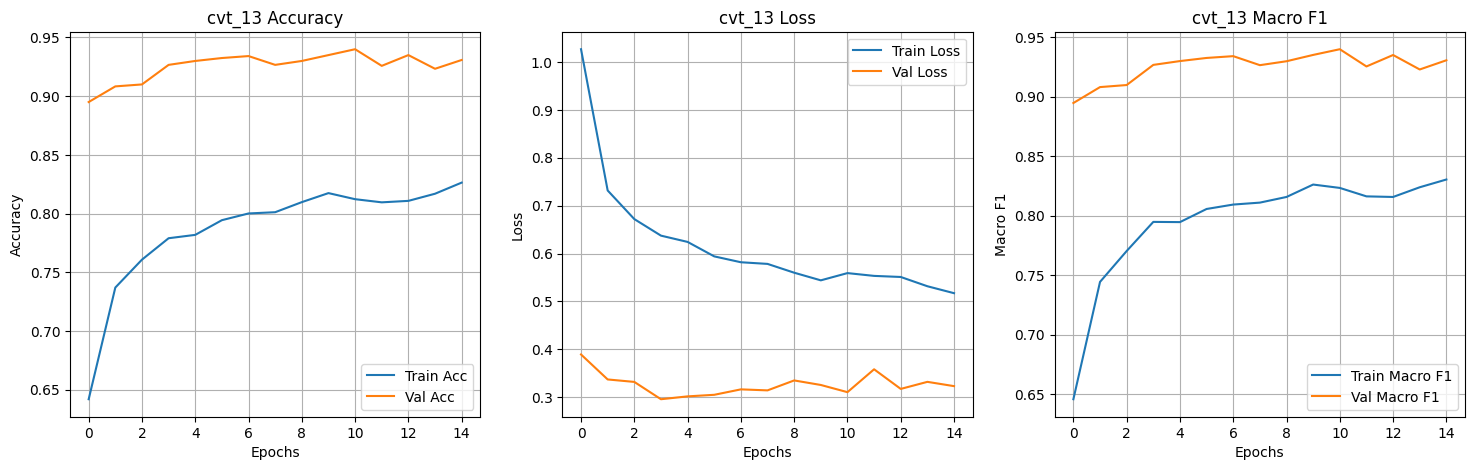

Grafikler kaydedildi: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\outputs\cvt_13\plots\aug\training_graph_cvt_13_dropout01_dp05_ls02_wd0p0005_bs32_ep50_lr8e-05_i224_augON_smpOFF_cwlON_ez112.png


In [9]:
plt.figure(figsize=(18, 5))
# Dogruluk grafigi
plt.subplot(1, 3, 1)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title(f'{MODEL_NAME} Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
# Kayip grafigi
plt.subplot(1, 3, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title(f'{MODEL_NAME} Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
# Macro F1 grafigi
plt.subplot(1, 3, 3)
plt.plot(history.get('train_macro_f1', []), label='Train Macro F1')
plt.plot(history.get('val_macro_f1', []), label='Val Macro F1')
plt.title(f'{MODEL_NAME} Macro F1')
plt.xlabel('Epochs')
plt.ylabel('Macro F1')
plt.legend()
plt.grid(True)
plot_path = os.path.join(PLOTS_DIR, f'training_graph_{MODEL_NAME}_{RUN_TAG}.png')
plt.savefig(plot_path)
plt.show()
print(f"Grafikler kaydedildi: {plot_path}")


TEST SETI DEGERLENDIRMESI

Siniflandirma Raporu:
                        precision    recall  f1-score   support

    dyed-lifted-polyps     0.9536    0.9536    0.9536       151
dyed-resection-margins     0.9539    0.9603    0.9571       151
           esophagitis     0.8971    0.8079    0.8502       151
          normal-cecum     0.9610    0.9801    0.9705       151
        normal-pylorus     0.9869    1.0000    0.9934       151
         normal-z-line     0.8293    0.9007    0.8635       151
                polyps     0.9667    0.9603    0.9635       151
    ulcerative-colitis     0.9797    0.9603    0.9699       151

              accuracy                         0.9404      1208
             macro avg     0.9410    0.9404    0.9402      1208
          weighted avg     0.9410    0.9404    0.9402      1208

Macro F1: 0.9402
Class recall degerleri:
  dyed-lifted-polyps: 0.9536
  dyed-resection-margins: 0.9603
  esophagitis: 0.8079
  normal-cecum: 0.9801
  normal-pylorus: 1.0000
  norm

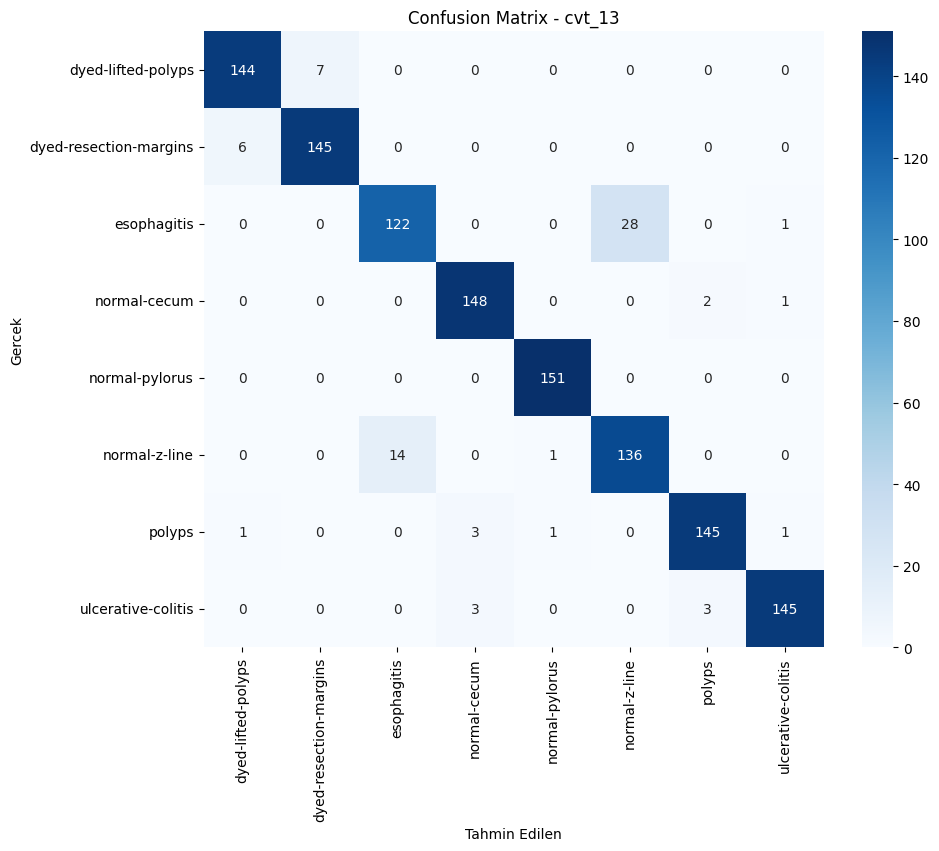

Confusion matrix kaydedildi: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\outputs\cvt_13\plots\aug\confusion_matrix_cvt_13_dropout01_dp05_ls02_wd0p0005_bs32_ep50_lr8e-05_i224_augON_smpOFF_cwlON_ez112.png
esophagitis <-> normal-z-line toplam hata: 42
dyed-lifted-polyps <-> dyed-resection-margins toplam hata: 13
Ablation sonuclari kaydedildi: c:\Users\mehme\OneDrive\Masaüstü\Gastroenterology-CNN-Comparison\outputs\cvt_13\ablation_results_cvt_13.csv
Son kayit:
                                                                                            run_name                                                                      run_tag model_name  batch_size  learning_rate  weight_decay  dropout_rate  drop_path_rate  label_smoothing  input_size  force_weighted_sampler  use_weighted_sampler  use_class_weighted_loss              target_class_weight_multipliers  early_stopping_patience early_stopping_metric  best_val_acc  best_val_loss  best_val_macro_f1  test_macro_f1  pa

In [8]:
print("\nTEST SETI DEGERLENDIRMESI")
model.eval()
y_true = []
y_pred = []
with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(DEVICE)
        outputs = get_logits(model(inputs))
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
# 1. Classification Report (F1, Recall, Precision)
print("\nSiniflandirma Raporu:")
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)
macro_f1 = f1_score(y_true, y_pred, average='macro')
class_recalls = recall_score(y_true, y_pred, average=None, labels=list(range(len(class_names))))
print(f"Macro F1: {macro_f1:.4f}")
print("Class recall degerleri:")
for class_name, rec in zip(class_names, class_recalls):
    print(f"  {class_name}: {rec:.4f}")
report_path = os.path.join(REPORTS_DIR, f'classification_report_{MODEL_NAME}_{RUN_TAG}.txt')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report)
    f.write(f"\nMacro F1: {macro_f1:.6f}\n")
    f.write("Class Recall:\n")
    for class_name, rec in zip(class_names, class_recalls):
        f.write(f"{class_name}: {rec:.6f}\n")
print(f"Rapor kaydedildi: {report_path}")
# 2. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gercek')
plt.title(f'Confusion Matrix - {MODEL_NAME}')
plot_path = os.path.join(PLOTS_DIR, f'confusion_matrix_{MODEL_NAME}_{RUN_TAG}.png')
plt.savefig(plot_path)
plt.show()
print(f"Confusion matrix kaydedildi: {plot_path}")
name_to_idx = {name: i for i, name in enumerate(class_names)}
pair_1_err = None
pair_2_err = None
if 'esophagitis' in name_to_idx and 'normal-z-line' in name_to_idx:
    i, j = name_to_idx['esophagitis'], name_to_idx['normal-z-line']
    pair_1_err = int(cm[i, j] + cm[j, i])
if 'dyed-lifted-polyps' in name_to_idx and 'dyed-resection-margins' in name_to_idx:
    i, j = name_to_idx['dyed-lifted-polyps'], name_to_idx['dyed-resection-margins']
    pair_2_err = int(cm[i, j] + cm[j, i])
if pair_1_err is not None:
    print(f"esophagitis <-> normal-z-line toplam hata: {pair_1_err}")
if pair_2_err is not None:
    print(f"dyed-lifted-polyps <-> dyed-resection-margins toplam hata: {pair_2_err}")
latest_metrics = {
    'run_name': RUN_NAME,
    'run_tag': RUN_TAG,
    'model_name': MODEL_NAME,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'weight_decay': WEIGHT_DECAY,
    'dropout_rate': DROPOUT_RATE,
    'drop_path_rate': DROP_PATH_RATE,
    'label_smoothing': LABEL_SMOOTHING,
    'input_size': INPUT_SIZE,
    'force_weighted_sampler': FORCE_WEIGHTED_SAMPLER,
    'use_weighted_sampler': train_sampler is not None,
    'use_class_weighted_loss': USE_CLASS_WEIGHTED_LOSS,
    'target_class_weight_multipliers': str(TARGET_CLASS_WEIGHT_MULTIPLIERS),
    'early_stopping_patience': EARLY_STOPPING_PATIENCE,
    'early_stopping_metric': EARLY_STOPPING_METRIC,
    'best_val_acc': float(max(history['val_acc'])) if 'history' in globals() else np.nan,
    'best_val_loss': float(min(history['val_loss'])) if 'history' in globals() else np.nan,
    'best_val_macro_f1': float(max(history['val_macro_f1'])) if 'history' in globals() and 'val_macro_f1' in history else np.nan,
    'test_macro_f1': float(macro_f1),
    'pair_err_esophagitis_normal_z_line': pair_1_err,
    'pair_err_dyed_lifted_vs_resection': pair_2_err
}
ablation_csv_path = os.path.join(RESULT_OUTPUT_DIR, f'ablation_results_{MODEL_NAME}.csv')
os.makedirs(os.path.dirname(ablation_csv_path), exist_ok=True)
new_row_df = pd.DataFrame([latest_metrics])
if os.path.exists(ablation_csv_path):
    old_df = pd.read_csv(ablation_csv_path)
    if 'run_tag' in old_df.columns:
        old_df = old_df[old_df['run_tag'] != RUN_TAG]
    result_df = pd.concat([old_df, new_row_df], ignore_index=True)
else:
    result_df = new_row_df
result_df.to_csv(ablation_csv_path, index=False)
print(f"Ablation sonuclari kaydedildi: {ablation_csv_path}")
print("Son kayit:")
print(new_row_df.to_string(index=False))